# 과제 1: Boosting 알고리즘 성능 비교  
California Housing 데이터를 사용해 세 가지 Boosting 알고리즘 비교하기  
데이터: sklearn.datasets.fetch_california_housing()  
- **모델 비교**
- AdaBoostRegressor
- GradientBoostingRegressor
- XGBRegressor

In [140]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
X, y = fetch_california_housing().data, fetch_california_housing().target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [141]:
models = {
    'AdaBoost_Regressor' : AdaBoostRegressor(random_state=42),
    'GB_Regressor' : GradientBoostingRegressor(random_state=42),
    'XGB_Regressor' : xgb.XGBRegressor(random_state=42)
}

for i, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred) 
    mae = mean_absolute_error(y_test, y_pred) 
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print('='*20)
    print(i)
    print(f'mse  : {mse:.3f}')
    print(f'mae  : {mae:.3f}')
    print(f'rmse : {rmse:.3f}')
    print(f'r2   : {r2:.3f}')

AdaBoost_Regressor
mse  : 0.028
mae  : 0.080
rmse : 0.168
r2   : 0.879
GB_Regressor
mse  : 0.031
mae  : 0.067
rmse : 0.177
r2   : 0.867
XGB_Regressor
mse  : 0.049
mae  : 0.071
rmse : 0.221
r2   : 0.793


---
# 과제 2: 과적합 제어 실험  
GradientBoostingClassifier로 과적합 제어 파라미터의 영향 분석  
데이터: Breast Cancer 데이터셋  

- **실험 내용**
- learning_rate: [0.01, 0.05, 0.1, 0.5]
- max_depth: [1, 3, 5, 7, None]
- subsample: [0.5, 0.7, 0.9, 1.0]
- 훈련/검증 평가

In [118]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

In [63]:
X, y = load_breast_cancer().data, load_breast_cancer().target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

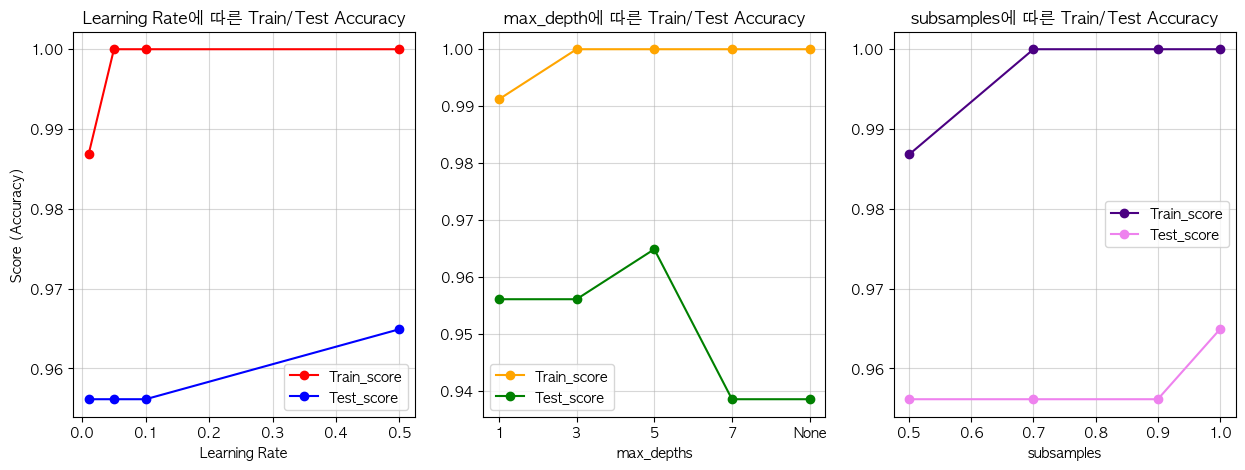

<Figure size 640x480 with 0 Axes>

In [138]:
learning_rates = [0.01, 0.05, 0.1, 0.5]
max_depths = [1, 3, 5, 7, None]
subsamples = [0.5, 0.7, 0.9, 1.0]

train_scores_lr = []
test_scores_lr = []
train_scores_md = []
test_scores_md = []
train_scores_ss = []
test_scores_ss = []

for lr in learning_rates:
    gb_lr = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=lr,
        random_state=42
    )

    gb_lr.fit(X_train, y_train)

    train_scores_lr.append(gb_lr.score(X_train, y_train))
    test_scores_lr.append(gb_lr.score(X_test, y_test))

for md in max_depths:
    
    gb_md = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=md,
        random_state=42
    )

    gb_md.fit(X_train, y_train)

    train_scores_md.append(gb_md.score(X_train, y_train))
    test_scores_md.append(gb_md.score(X_test, y_test))

for ss in subsamples:
    
    gb_ss = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=md,
        random_state=42
    )

    gb_ss.fit(X_train, y_train)

    train_scores_ss.append(gb_ss.score(X_train, y_train))
    test_scores_ss.append(gb_ss.score(X_test, y_test))


# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].plot(learning_rates, train_scores_lr, label='Train_score', c='red', marker='o')
axes[0].plot(learning_rates, test_scores_lr, label='Test_score', c='blue', marker='o')
axes[0].set_title('Learning Rate에 따른 Train/Test Accuracy')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Score (Accuracy)')
axes[0].grid(alpha=0.5)
axes[0].legend()

axes[1].plot([str(md) for md in max_depths], train_scores_md, label='Train_score', c='orange', marker='o')
axes[1].plot([str(md) for md in max_depths], test_scores_md, label='Test_score', c='green', marker='o')
axes[1].set_title('max_depth에 따른 Train/Test Accuracy')
axes[1].set_xlabel('max_depths')
axes[1].grid(alpha=0.5)
axes[1].legend()

axes[2].plot(subsamples, train_scores, label='Train_score', c='indigo', marker='o')
axes[2].plot(subsamples, test_scores, label='Test_score', c='violet', marker='o')
axes[2].set_title('subsamples에 따른 Train/Test Accuracy')
axes[2].set_xlabel('subsamples')
axes[2].grid(alpha=0.5)
axes[2].legend()

plt.show()
plt.tight_layout()